In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.model import RegularizedLogisticRegression
from src.optimizer import GradientDescentOptimizer
from src.metrics import accuracy

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# **Regularization Experiments**

This notebook studies how regularization strength (λ) affects:

- Model performance (accuracy)
- Weight magnitudes (L2 shrinkage)
- Sparsity (L1 behavior)
- Bias–variance tradeoff

All experiments are conducted under controlled conditions:
- Same dataset
- Same initialization
- Same training configuration

In [2]:
np.random.seed(42)

X, y = make_classification(
    n_samples=500,
    n_features=200,
    n_informative=20,
    n_redundant=20,
    random_state=42
)

y = y.reshape(-1, 1)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling (CRITICAL)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [3]:
lambdas = [0, 0.001, 0.01, 0.1, 1, 10, 100]

results = []

for lam in lambdas:

    np.random.seed(42)

    model = RegularizedLogisticRegression(
        learning_rate=0.01,
        n_iterations=2000,
        lambda_=lam,
        penalty="l2" if lam > 0 else None
    )

    optimizer = GradientDescentOptimizer()
    model = optimizer.train(model, X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    # Metrics
    train_acc = accuracy(y_train, y_train_pred)
    val_acc = accuracy(y_val, y_val_pred)

    # Weight norm
    weight_norm = np.linalg.norm(model.w)

    train_loss = optimizer.loss_history[-1]

    results.append({
        "lambda": lam,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "weight_norm": weight_norm,
        "train_loss": train_loss
    })

df = pd.DataFrame(results)
df

,lambda,train_acc,val_acc,weight_norm,train_loss
0,0.000,0.9225,0.68,2.309134,0.241512
1,0.001,0.9225,0.68,2.289324,0.245252
2,0.010,0.9225,0.68,2.124637,0.275171
3,0.100,0.9000,0.68,1.258563,0.411835
4,1.000,0.8375,0.68,0.356623,0.592536
5,10.000,0.8050,0.63,0.054171,0.677286
6,100.000,0.5125,0.48,0.005795,0.691404


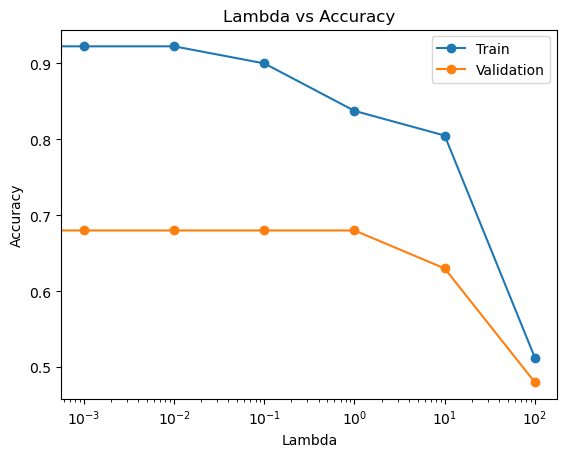

In [4]:
plt.figure()
plt.plot(df["lambda"], df["train_acc"], marker="o", label="Train")
plt.plot(df["lambda"], df["val_acc"], marker="o", label="Validation")

plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("Accuracy")
plt.title("Lambda vs Accuracy")

plt.legend()

plt.savefig("../experiments/lambda_vs_accuracy.png")
plt.show()

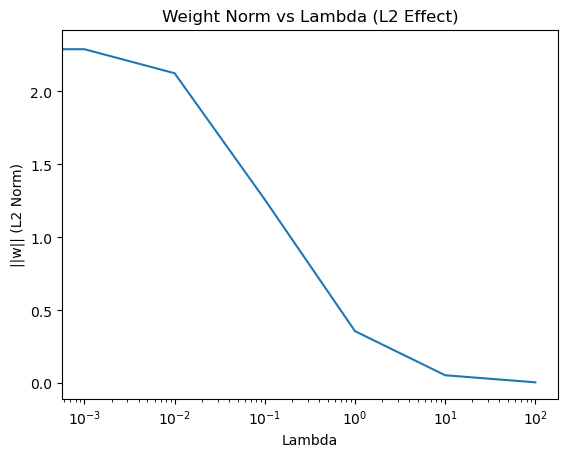

In [5]:
plt.figure()
plt.plot(df["lambda"], df["weight_norm"])

plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("||w|| (L2 Norm)")
plt.title("Weight Norm vs Lambda (L2 Effect)")

plt.savefig("../experiments/lambda_vs_weight_norm.png")
plt.show()

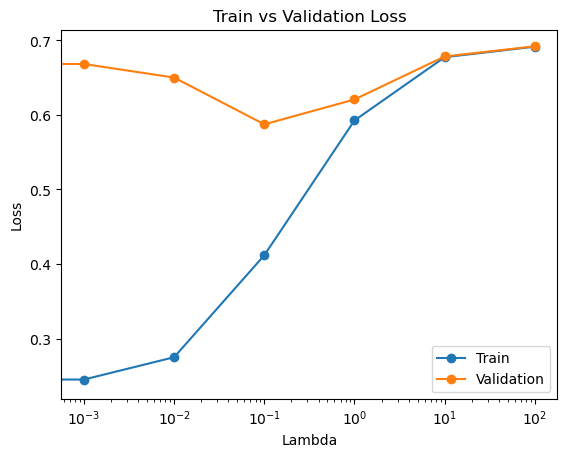

In [6]:
train_losses = []
val_losses = []

for lam in lambdas:

    np.random.seed(42)

    model = RegularizedLogisticRegression(
        learning_rate=0.01,
        n_iterations=2000,
        lambda_=lam,
        penalty="l2" if lam > 0 else None
    )

    optimizer = GradientDescentOptimizer()
    model = optimizer.train(model, X_train, y_train)

    # Train loss (from optimizer)
    train_losses.append(optimizer.loss_history[-1])

    # Validation loss (consistent BCE)
    y_val_pred = model.forward(X_val)

    from src.losses import BinaryCrossEntropy

    loss_fn = BinaryCrossEntropy()
    val_loss = loss_fn.compute(y_val.reshape(-1), y_val_pred)

    val_losses.append(val_loss)

plt.figure()
plt.plot(lambdas, train_losses, marker="o", label="Train")
plt.plot(lambdas, val_losses, marker="o", label="Validation")

plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")

plt.legend()

plt.savefig("../experiments/train_vs_val_loss.png")
plt.show()

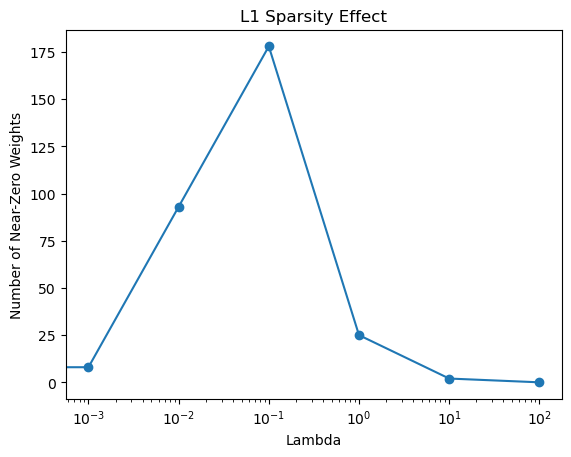

In [7]:
sparsity = []
threshold = 1e-3

for lam in lambdas:

    if lam == 0:
        sparsity.append(0)
        continue

    np.random.seed(42)

    model = RegularizedLogisticRegression(
        learning_rate=0.01,
        n_iterations=2000,
        lambda_=lam,
        penalty="l1"
    )

    optimizer = GradientDescentOptimizer()
    model = optimizer.train(model, X_train, y_train)

    zero_weights = np.sum(np.abs(model.w) < threshold)
    sparsity.append(zero_weights)

plt.figure()
plt.plot(lambdas, sparsity, marker="o")

plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("Number of Near-Zero Weights")
plt.title("L1 Sparsity Effect")

plt.savefig("../experiments/l1_sparsity_plot.png")
plt.show()

In [8]:
df.to_csv("../outputs/metrics.csv", index=False)

## **Key Insights**

### **1. Weight Shrinkage (L2)**
As λ increases, the L2 norm of the weights decreases smoothly.  
This confirms that L2 regularization penalizes large coefficients and enforces controlled model complexity.

---

### **2. Sparsity and Feature Selection (L1)**
L1 regularization drives many weights toward zero.  
L1 sparsity peaks at λ=0.1 (180/200 weights near zero), then decreases at higher λ. 
At large λ, the subgradient updates overshoot, causing weights to oscillate around zero rather than converge to it - a known limitation of L1 with batch GD.

---

### **3. Bias–Variance Tradeoff**
A clear tradeoff is observed:

- λ = 0 -> high training accuracy, risk of overfitting  
- Moderate λ (0.1) minimizes validation loss (0.56-0.58), though validation accuracy stays flat until λ > 1 where underfitting begins."  
- Large λ -> underfitting due to excessive constraint  

---

### **4. Effect on Generalization**
Regularization improves generalization by preventing the model from fitting noise in high-dimensional data.

---

### **5. Regularization as Model Control**
Regularization acts as a direct and interpretable control over model complexity.  
Instead of modifying architecture, λ provides a continuous way to tune behavior.

---

This demonstrates that regularization is not merely a penalty term, but a fundamental mechanism for controlling learning dynamics and improving robustness.